# SMAP Pixel Land-Use Composition
This notebook computes land-use classes inside a SMAP pixel and reports area percentage by class.

In [ ]:
# Install if needed: pip install geopandas pandas matplotlib pyproj
from pathlib import Path
import warnings

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

In [ ]:
# Update these paths to your files (defaults resolve within this workspace)
base_dir = Path.cwd()
if not (base_dir / "data").exists() and (base_dir.parent / "data").exists():
    base_dir = base_dir.parent

smap_pixel_shape = base_dir / "data" / "smap" / "SMAP_pixel.shp"
landuse_path = base_dir / "data" / "cobertura" / "Cobertura_vegetal_ECUADOR_2022_100k_UTM_WGS84_17S.shp"

# Optional: where to save output CSV
output_csv = base_dir / "resultados" / "smap_pixel_landuse_percentages.csv"

print('SMAP pixel:', smap_pixel_shape)
print('Land use :', landuse_path)
print('CSV out  :', output_csv)

SMAP pixel: c:\Soilgrids\data\smap\SMAP_pixel.shp
Land use : c:\Soilgrids\data\cobertura\Cobertura_vegetal_ECUADOR_2022_100k_UTM_WGS84_17S.shp
CSV out  : c:\Soilgrids\resultados\smap_pixel_landuse_percentages.csv


In [17]:
# Read shapefiles
smap = gpd.read_file(smap_pixel_shape)
landuse = gpd.read_file(landuse_path)

print('SMAP features   :', len(smap))
print('Land-use features:', len(landuse))
print('SMAP CRS   :', smap.crs)
print('Land-use CRS:', landuse.crs)

SMAP features   : 1
Land-use features: 279077
SMAP CRS   : EPSG:4326
Land-use CRS: EPSG:32717


In [18]:
# Choose a projected CRS to compute area in square meters
# Prefer UTM 17S (EPSG:32717) given your data description.
target_crs = 'EPSG:32717'

if smap.crs is None or landuse.crs is None:
    raise ValueError('One or both layers have no CRS defined. Define CRS before analysis.')

smap_proj = smap.to_crs(target_crs)
landuse_proj = landuse.to_crs(target_crs)

# Dissolve SMAP to a single polygon in case it contains multiple parts
smap_union = smap_proj.dissolve()
smap_union = smap_union[['geometry']].copy()

# Clip land use to SMAP extent for performance
landuse_clip = gpd.clip(landuse_proj, smap_union)

print('Land-use features intersecting SMAP:', len(landuse_clip))

Land-use features intersecting SMAP: 21


In [6]:
# Identify land-use attribute column
print('Land-use columns:')
print(list(landuse_clip.columns))

# Use the confirmed land-use class field
landuse_col = 'ctn2'
if landuse_col not in landuse_clip.columns:
    raise ValueError(f"Expected land-use column '{landuse_col}' not found. Available: {list(landuse_clip.columns)}")

print('Using land-use category column:', landuse_col)

Land-use columns:
['objectid', 'fcode', 'ctn1', 'ctn2', 'anio', 'are', 'vuln_score', 'geometry']
Using land-use category column: ctn2


In [7]:
# Intersect and calculate area per land-use class
intersections = gpd.overlay(
    landuse_clip[[landuse_col, 'geometry']].copy(),
    smap_union[['geometry']].copy(),
    how='intersection'
)

if intersections.empty:
    raise ValueError('No overlap found between SMAP pixel and land-use polygons.')

intersections['area_m2'] = intersections.geometry.area
total_area_m2 = intersections['area_m2'].sum()

summary = (
    intersections.groupby(landuse_col, dropna=False)['area_m2']
    .sum()
    .reset_index()
    .sort_values('area_m2', ascending=False)
)
summary['pct_of_smap'] = 100.0 * summary['area_m2'] / total_area_m2
summary['area_ha'] = summary['area_m2'] / 10000.0

# Reorder columns
summary = summary[[landuse_col, 'area_m2', 'area_ha', 'pct_of_smap']]

# Nice formatting copy for display
summary_display = summary.copy()
summary_display['area_m2'] = summary_display['area_m2'].round(2)
summary_display['area_ha'] = summary_display['area_ha'].round(4)
summary_display['pct_of_smap'] = summary_display['pct_of_smap'].round(2)

print(f'Total intersected area: {total_area_m2:,.2f} m2')
summary_display

Total intersected area: 111,330,021.95 m2


,ctn2,area_m2,area_ha,pct_of_smap
3,PARAMO,1.093899e+08,10938.9872,98.26
4,PASTIZAL,9.054000e+05,90.5400,0.81
1,CUERPO DE AGUA NATURAL,5.240650e+05,52.4065,0.47
5,PLANTACION FORESTAL,2.730854e+05,27.3085,0.25
2,INFRAESTRUCTURA,2.313000e+05,23.1300,0.21
0,BOSQUE NATIVO,6.300000e+03,0.6300,0.01


In [ ]:
# Save results
output_csv.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(output_csv, index=False)
print('Saved:', output_csv)

Saved: c:\Bachelorarbeit\resultados\smap_pixel_landuse_percentages.csv


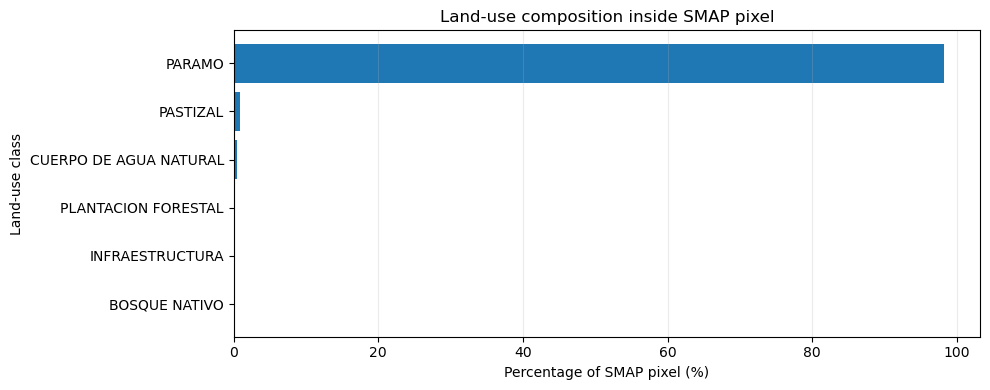

In [ ]:
# Plot percentage composition
plot_df = summary_display.sort_values('pct_of_smap', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(plot_df))))
ax.barh(plot_df[landuse_col].astype(str), plot_df['pct_of_smap'])
ax.set_xlabel('Percentage of SMAP pixel (%)')
ax.set_ylabel('Land-use class')
ax.set_title('Land-use composition inside SMAP pixel')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

NDVI distribution summary:
count    1.121481e+06
mean     4.827477e-01
std      1.123773e-01
min     -6.111111e-01
5%       3.202323e-01
25%      4.038826e-01
50%      4.720598e-01
75%      5.584872e-01
95%      6.775035e-01
max      8.768752e-01
Name: NDVI, dtype: float64

Point NDVI (TIFF at coord): 0.4643
Percentile within SMAP pixel distribution: 47.22%


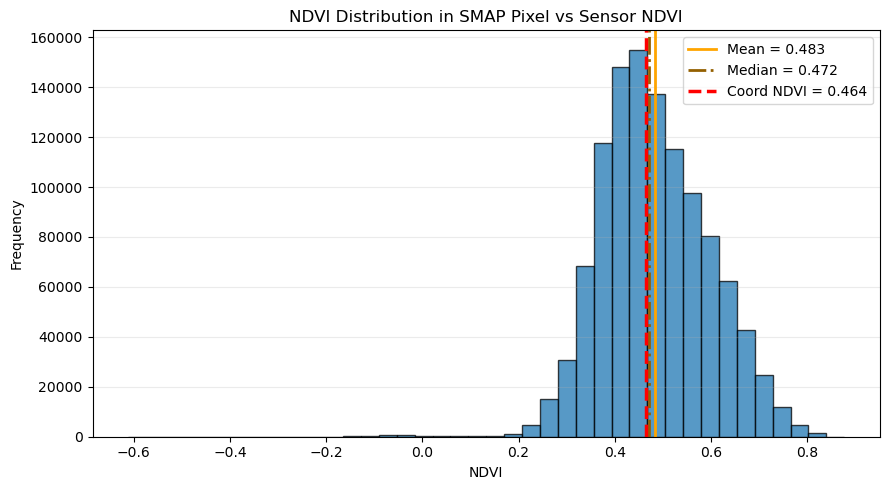

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Inputs
coord_lon, coord_lat = -79.234636, -3.062424
csv_path = Path(r"C:\Soilgrids\data\smap\SMAP_NDVI_distribution_AugNov_2022.csv")
tif_path = Path(r"C:\Soilgrids\data\smap\SMAP_NDVI_composite_AugNov_2022.tif")

# Optional fallback if you already know point NDVI from another source
manual_point_ndvi = None  # e.g., 0.76

if not csv_path.exists():
    raise FileNotFoundError(f"CSV not found: {csv_path}")

# Read NDVI distribution
df = pd.read_csv(csv_path)
if "NDVI" not in df.columns:
    raise ValueError(f"Column 'NDVI' not found. Available columns: {list(df.columns)}")

ndvi = pd.to_numeric(df["NDVI"], errors="coerce").dropna()
if ndvi.empty:
    raise ValueError("No valid NDVI values found in CSV.")

# Try to get point NDVI directly from raster at the coordinate
point_ndvi = None
point_source = None

if tif_path.exists():
    try:
        import rasterio
        from pyproj import Transformer

        with rasterio.open(tif_path) as src:
            # Transform lon/lat (EPSG:4326) to raster CRS when needed
            x, y = coord_lon, coord_lat
            if src.crs is not None and str(src.crs).upper() not in ["EPSG:4326", "OGC:CRS84"]:
                transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
                x, y = transformer.transform(coord_lon, coord_lat)

            row, col = src.index(x, y)
            arr = src.read(1)
            val = arr[row, col]

            if src.nodata is not None and np.isclose(val, src.nodata):
                point_ndvi = np.nan
            else:
                point_ndvi = float(val)
                # Scale integer NDVI products if needed (common scale factor 10000)
                if point_ndvi > 1.0:
                    point_ndvi = point_ndvi / 10000.0
                point_source = "TIFF at coord"
    except Exception as e:
        print(f"Could not extract NDVI from TIFF: {e}")

# Fallback to manual value if raster extraction is unavailable
if point_ndvi is None and manual_point_ndvi is not None:
    point_ndvi = float(manual_point_ndvi)
    point_source = "manual"

# Summary stats and percentile
desc = ndvi.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
print("NDVI distribution summary:")
print(desc)

if point_ndvi is not None and not np.isnan(point_ndvi):
    percentile = (ndvi <= point_ndvi).mean() * 100
    print(f"\nPoint NDVI ({point_source}): {point_ndvi:.4f}")
    print(f"Percentile within SMAP pixel distribution: {percentile:.2f}%")
else:
    print("\nPoint NDVI not available. Set manual_point_ndvi or verify TIFF path/CRS.")

# Plot histogram + point marker
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ndvi, bins=40, alpha=0.75, edgecolor="black")
ax.axvline(ndvi.mean(), linestyle="-", linewidth=2, color="orange", label=f"Mean = {ndvi.mean():.3f}")
ax.axvline(ndvi.median(), linestyle="-.", linewidth=2, color="#946001", label=f"Median = {ndvi.median():.3f}")


ax.axvline(point_ndvi, linestyle="--", linewidth=2.5, color="red", label=f"Coord NDVI = {point_ndvi:.3f}")

ax.set_xlabel("NDVI")
ax.set_ylabel("Frequency")
ax.set_title("NDVI Distribution in SMAP Pixel vs Sensor NDVI")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

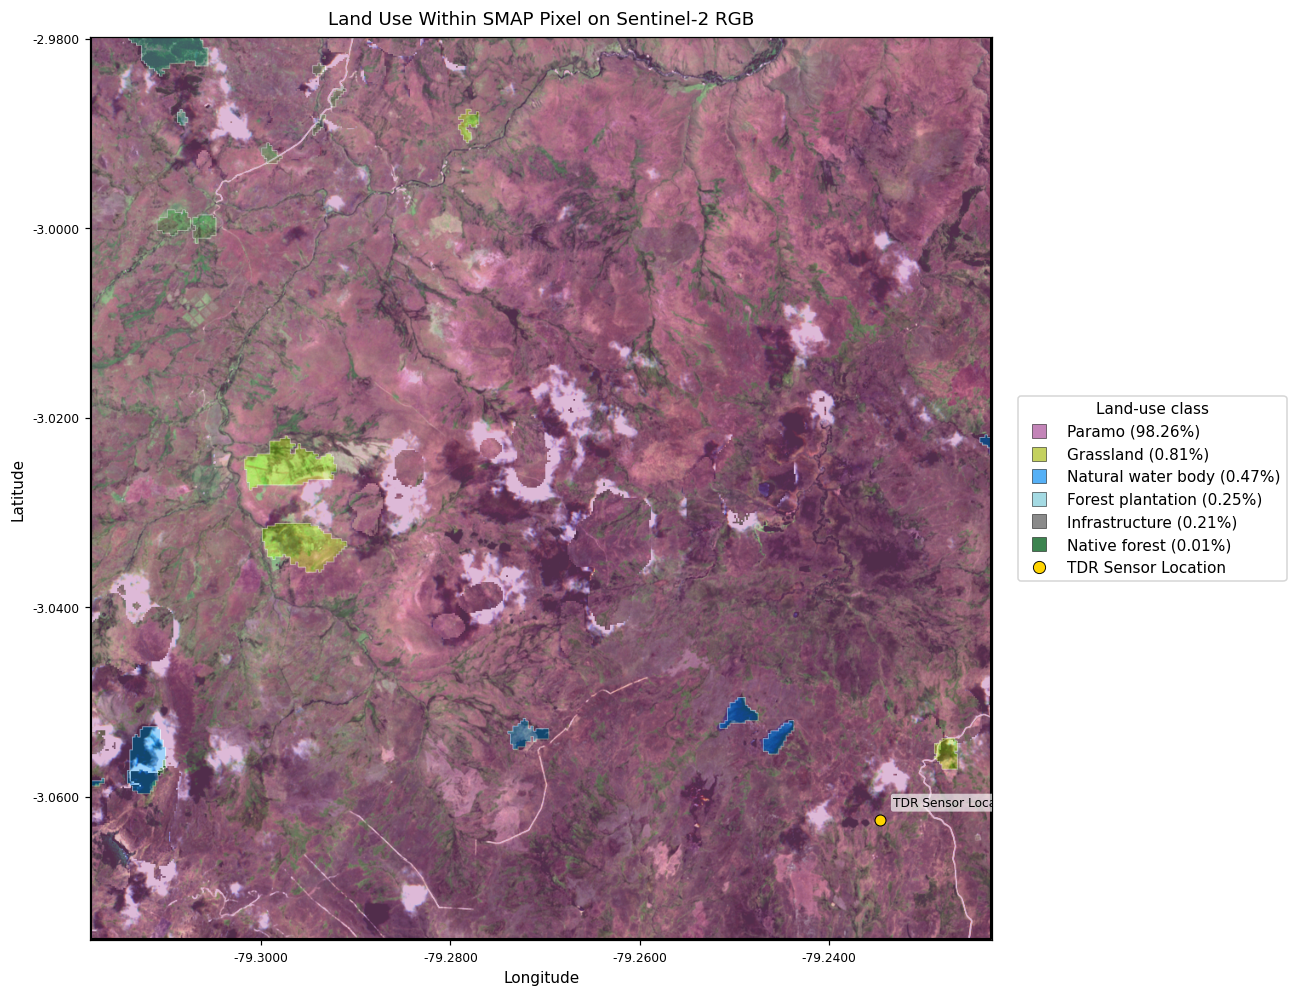

In [35]:
# Map land-use classes within the SMAP pixel over Sentinel-2 RGB composite
from pathlib import Path
import numpy as np
import rasterio
from rasterio.plot import show as rioshow
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

if 'intersections' not in globals() or intersections.empty:
    raise ValueError('Run the previous intersection cell first to build intersections.')

# Prepare land-use geometries
map_gdf = intersections[[landuse_col, 'geometry']].copy()
map_gdf[landuse_col] = map_gdf[landuse_col].fillna('No data').astype(str)

# Translate classes to English
class_translation = {
    'BOSQUE NATIVO': 'Native forest',
    'CUERPO DE AGUA NATURAL': 'Natural water body',
    'INFRAESTRUCTURA': 'Infrastructure',
    'PARAMO': 'Paramo',
    'PASTIZAL': 'Grassland',
    'PLANTACION FORESTAL': 'Forest plantation',
    'No data': 'No data'
}
map_gdf['class_en'] = map_gdf[landuse_col].map(class_translation).fillna(map_gdf[landuse_col])

# Fixed, sensible palette by class (consistent across runs)
class_to_color = {
    'Native forest': '#0b6623',
    'Natural water body': '#2a9df4',
    'Infrastructure': '#6d6d6d',
    'Paramo': '#b565a7',
    'Grassland': '#b6c637',
    'Forest plantation': '#8ed1dc',
    'No data': '#f2f2f2'
}

# Keep consistent legend order from area summary
ordered_src_classes = summary_display[landuse_col].astype(str).tolist()
ordered_classes = [class_translation.get(c, c) for c in ordered_src_classes]
for cls in sorted(map_gdf['class_en'].unique()):
    if cls not in ordered_classes:
        ordered_classes.append(cls)

# Add user-provided sensor coordinate (lon, lat in EPSG:4326)
sensor_label = 'TDR Sensor Location'
sensor_lon, sensor_lat = -79.234636, -3.062424
sensor_points = gpd.GeoDataFrame(
    {'label': [sensor_label], 'longitude': [sensor_lon], 'latitude': [sensor_lat]},
    geometry=gpd.points_from_xy([sensor_lon], [sensor_lat]),
    crs='EPSG:4326'
)

rgb_path = base_dir / 'data' / 'smap' / 'SMAP_RGB_composite_AugNov_2022.tif'

if rgb_path.exists():
    with rasterio.open(rgb_path) as src:
        # Reproject overlays to raster CRS for correct alignment
        map_plot = map_gdf.to_crs(src.crs) if map_gdf.crs != src.crs else map_gdf
        smap_boundary_plot = smap_union.to_crs(src.crs) if smap_union.crs != src.crs else smap_union
        sensor_plot = sensor_points.to_crs(src.crs)

        # Read only a local raster window around the SMAP pixel to avoid large-memory plotting
        minx, miny, maxx, maxy = smap_boundary_plot.total_bounds
        pad_x = (maxx - minx) * 0.001
        pad_y = (maxy - miny) * 0.001
        xmin, ymin = minx - pad_x, miny - pad_y
        xmax, ymax = maxx + pad_x, maxy + pad_y

        # Figure sized to match the data's real aspect ratio (removes empty top/bottom bands)
        data_aspect = (xmax - xmin) / (ymax - ymin)
        fig_height = 9
        fig_width = fig_height * data_aspect + 3  # extra width reserved for legend
        fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=110)

        window = from_bounds(xmin, ymin, xmax, ymax, transform=src.transform)
        window = window.round_offsets().round_lengths()

        # boundless=True keeps the array/transform consistent even when the window
        # extends past what GEE actually exported
        rgb = src.read([1, 2, 3], window=window, boundless=True, fill_value=0).astype('float32')
        rgb_transform = src.window_transform(window)

        # Track which pixels are genuine "no data" (all bands 0 from boundless padding)
        nodata_mask = np.all(rgb == 0, axis=0)

        # Percentile stretch for contrast, computed only over real (non-padded) pixels
        for i in range(3):
            band = rgb[i]
            valid = band[~nodata_mask]
            lo = np.nanpercentile(valid, 2) if valid.size else 0
            hi = np.nanpercentile(valid, 98) if valid.size else 1
            if hi > lo:
                band = (band - lo) / (hi - lo)
            rgb[i] = np.clip(band, 0, 1)

        # Force no-data pixels to white instead of black
        for i in range(3):
            rgb[i][nodata_mask] = 1.0

        rioshow(rgb, transform=rgb_transform, ax=ax)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        plot_bounds = (xmin, ymin, xmax, ymax)
else:
    print(f'RGB composite not found at: {rgb_path}')
    print('Plotting land use without raster background.')
    map_plot = map_gdf.copy()
    smap_boundary_plot = smap_union.copy()
    sensor_plot = sensor_points.to_crs(map_plot.crs) if sensor_points.crs != map_plot.crs else sensor_points
    lft, btm, rgt, top = smap_boundary_plot.total_bounds

    data_aspect = (rgt - lft) / (top - btm)
    fig_height = 9
    fig_width = fig_height * data_aspect + 3
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=110)
    ax.set_facecolor('white')

    plot_bounds = (lft, btm, rgt, top)
    ax.set_xlim(lft, rgt)
    ax.set_ylim(btm, top)

# Plot each class with partial transparency for overlay readability
for cls in ordered_classes:
    cls_mask = map_plot['class_en'] == cls
    if cls_mask.any():
        map_plot.loc[cls_mask].plot(
            ax=ax,
            color=class_to_color.get(cls, '#cccccc'),
            edgecolor='white',
            linewidth=0.35,
            alpha=0.45
        )

smap_boundary_plot.boundary.plot(ax=ax, color='black', linewidth=1.4)

# Plot sensor point and label
sensor_plot.plot(ax=ax, color='#ffd400', edgecolor='black', marker='o', markersize=52, linewidth=0.7, zorder=5)

# Use small, extent-based label offsets to avoid huge plot bounds
x_span = max(plot_bounds[2] - plot_bounds[0], 1e-9)
y_span = max(plot_bounds[3] - plot_bounds[1], 1e-9)
x_offset = x_span * 0.015
y_offset = y_span * 0.015

for _, row in sensor_plot.iterrows():
    ax.text(
        row.geometry.x + x_offset,
        row.geometry.y + y_offset,
        str(row['label']),
        fontsize=8,
        color='black',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.65, boxstyle='round,pad=0.2'),
        zorder=6,
        clip_on=True
    )

# Build legend labels with English names and percentages
pct_lookup = dict(zip(summary_display[landuse_col].astype(str), summary_display['pct_of_smap']))
handles = []
for src_cls, en_cls in zip(ordered_src_classes, ordered_classes[:len(ordered_src_classes)]):
    handles.append(
        plt.Line2D(
            [0], [0], marker='s', color='none',
            markerfacecolor=class_to_color.get(en_cls, '#cccccc'),
            markeredgecolor='black', markeredgewidth=0.4,
            markersize=9, alpha=0.8,
            label=f"{en_cls} ({pct_lookup.get(src_cls, 0):.2f}%)"
        )
    )

handles.append(
    plt.Line2D(
        [0], [0], marker='o', color='none',
        markerfacecolor='#ffd400', markeredgecolor='black', markeredgewidth=0.6,
        markersize=8, label=sensor_label
    )
)

ax.legend(handles=handles, title='Land-use class', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
ax.set_title('Land Use Within SMAP Pixel on Sentinel-2 RGB', pad=8)

# Show lat/lon on the axes instead of turning them off completely
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
ax.tick_params(axis='both', labelsize=8)

plt.tight_layout(pad=0.5)
plt.savefig('smap_landuse.png', bbox_inches='tight', pad_inches=0.15, dpi=150)
plt.show()